Connected to Python 3.14.3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from warnings import filterwarnings

filterwarnings('ignore')

In [ ]:
df = pd.read_csv("all_fuels_data.csv")
df.head()

,ticker,commodity,date,open,high,low,close,volume
0,CL=F,Crude Oil,2000-08-23,31.950001,32.799999,31.950001,32.049999,79385
1,CL=F,Crude Oil,2000-08-24,31.900000,32.240002,31.400000,31.629999,72978
2,CL=F,Crude Oil,2000-08-25,31.700001,32.099998,31.320000,32.049999,44601
3,CL=F,Crude Oil,2000-08-28,32.040001,32.919998,31.860001,32.869999,46770
4,CL=F,Crude Oil,2000-08-29,32.820000,33.029999,32.560001,32.720001,49131


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28075 entries, 0 to 28074
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ticker     28075 non-null  object 
 1   commodity  28075 non-null  object 
 2   date       28075 non-null  object 
 3   open       28075 non-null  float64
 4   high       28075 non-null  float64
 5   low        28075 non-null  float64
 6   close      28075 non-null  float64
 7   volume     28075 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 1.7+ MB


In [ ]:
df.shape

(28075, 8)

In [ ]:
df.dtypes

ticker        object
commodity     object
date          object
open         float64
high         float64
low          float64
close        float64
volume         int64
dtype: object

In [ ]:
df.describe()


# * The dataset contains 28,075 rows across 5 commodity futures (Crude Oil, Brent Crude,
#   Heating Oil, Natural Gas, RBOB Gasoline) spanning 2000–2024. All 8 columns are
#   present with no missing values. Price columns are float64 and volume is int64.
#   Descriptive statistics reveal significant price variation across commodities,
#   confirming the need for per-commodity normalization via returns.

# ### 2. Date parsing, sorting and gap analysis

,open,high,low,close,volume
count,28075.000000,28075.000000,28075.000000,28075.000000,2.807500e+04
mean,27.288994,27.680580,26.873389,27.287224,1.059926e+05
std,36.085625,36.540236,35.599243,36.089001,1.484400e+05
min,-14.000000,0.507000,-40.320000,-37.630001,0.000000e+00
25%,2.031000,2.060550,1.998200,2.031250,2.641100e+04
50%,3.374000,3.450000,3.301000,3.375900,4.903300e+04
75%,54.895000,55.745001,53.910000,54.900000,1.147245e+05
max,146.080002,147.429993,144.270004,146.080002,2.288230e+06


In [ ]:
df["date"]= pd.to_datetime(df["date"])

In [ ]:
df = df.sort_values(by='date').reset_index(drop=True)

# each commodity should appear in both early and late rows
print("Date range check per commodity:")
print(df.groupby('commodity')['date'].agg(['min','max']))

Date range check per commodity:
                       min        max
commodity                            
Brent Crude Oil 2007-07-30 2024-06-24
Crude Oil       2000-08-23 2024-06-24
Heating Oil     2000-09-01 2024-06-24
Natural Gas     2000-08-30 2024-06-24
RBOB Gasoline   2000-11-01 2024-06-24


In [ ]:
df.dtypes

ticker               object
commodity            object
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume                int64
dtype: object

In [ ]:
df["date"].unique()

<DatetimeArray>
['2000-08-23 00:00:00', '2000-08-24 00:00:00', '2000-08-25 00:00:00',
 '2000-08-28 00:00:00', '2000-08-29 00:00:00', '2000-08-30 00:00:00',
 '2000-08-31 00:00:00', '2000-09-01 00:00:00', '2000-09-05 00:00:00',
 '2000-09-06 00:00:00',
 ...
 '2024-06-10 00:00:00', '2024-06-11 00:00:00', '2024-06-12 00:00:00',
 '2024-06-13 00:00:00', '2024-06-14 00:00:00', '2024-06-17 00:00:00',
 '2024-06-18 00:00:00', '2024-06-20 00:00:00', '2024-06-21 00:00:00',
 '2024-06-24 00:00:00']
Length: 5990, dtype: datetime64[ns]

In [ ]:
# Calculate date difference per commodity
df['date_diff'] = df.groupby('commodity')['date'].diff()

# Show unique gaps
df['date_diff'].value_counts().head()

date_diff
1 days    21984
3 days     5016
4 days      774
2 days      236
5 days       59
Name: count, dtype: int64

In [ ]:
df['date_diff'].unique()

<TimedeltaArray>
[NaT, '1 days', '3 days', '4 days', '5 days', '2 days', '17 days']
Length: 7, dtype: timedelta64[ns]

In [ ]:
# Find rows where gap is more than 1 day
missing_dates = df[df['date_diff'] > pd.Timedelta(days=1)]

missing_dates[['commodity', 'date', 'date_diff']].head(10)


# * The date column was converted to datetime format to enable time-series operations.
#   Records were sorted by commodity then date to ensure correct rolling window
#   calculations. Date gap analysis confirms only weekend and holiday gaps (2–3 days)
#   are present — no missing trading periods that would distort feature engineering.

# ### 3. Data quality validation

,commodity,date,date_diff
3,Crude Oil,2000-08-28,3 days
12,Natural Gas,2000-09-05,4 days
13,Heating Oil,2000-09-05,4 days
14,Crude Oil,2000-09-05,4 days
24,Crude Oil,2000-09-11,3 days
25,Natural Gas,2000-09-11,3 days
26,Heating Oil,2000-09-11,3 days
39,Crude Oil,2000-09-18,3 days
40,Heating Oil,2000-09-18,3 days
41,Natural Gas,2000-09-18,3 days


In [ ]:
df.isnull().sum()

ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
date_diff    5
dtype: int64

In [ ]:
df[df.duplicated()]

,ticker,commodity,date,open,high,low,close,volume,date_diff


In [ ]:
df[df.duplicated()]

,ticker,commodity,date,open,high,low,close,volume,date_diff


In [ ]:
df["ticker"].unique()

array(['CL=F', 'NG=F', 'HO=F', 'RB=F', 'BZ=F'], dtype=object)

In [ ]:
df["commodity"].unique()

array(['Crude Oil', 'Natural Gas', 'Heating Oil', 'RBOB Gasoline',
       'Brent Crude Oil'], dtype=object)

In [ ]:
df['open'].unique()

array([31.95000076, 31.89999962, 31.70000076, ...,  2.52589989,
        2.50230002, 85.68000031], shape=(17035,))

In [ ]:
df['open'].unique()

array([31.95000076, 31.89999962, 31.70000076, ...,  2.52589989,
        2.50230002, 85.68000031], shape=(17035,))

In [ ]:
len(df['open'].unique())

17035

In [ ]:
(df[['open', 'high', 'low', 'close']] <= 0).sum()


# > A small number of non-positive price values were detected.
# > Commodities prices cannot be ≤ 0, so these require row-level inspection
# > to determine if they are data errors or genuine market events.
# 

open     1
high     0
low      2
close    1
dtype: int64

In [ ]:
(df[['open', 'high', 'low', 'close']] <= 0).sum()


# > A small number of non-positive price values were detected.
# > Commodities prices cannot be ≤ 0, so these require row-level inspection
# > to determine if they are data errors or genuine market events.
# 

open     1
high     0
low      2
close    1
dtype: int64

In [ ]:
df.loc[
    (df['open'] <= 0) | 
    (df['low'] <= 0) | 
    (df['close'] <= 0),
    ['ticker','commodity','date','open','high','low','close','volume']
]


# * Inspection reveals negative close prices exclusively in Crude Oil during April 2020,
#   corresponding to the historic WTI price collapse (lowest: -$37.63) caused by
#   COVID-19 storage constraints. These are genuine market events, not data errors,
#   and are retained. Simple percentage returns will be used instead of log returns
#   to handle these values safely.

#  ### 4. Price history — time vs close price

,ticker,commodity,date,open,high,low,close,volume
22814,CL=F,Crude Oil,2020-04-20,17.73,17.85,-40.32,-37.630001,247947
22822,CL=F,Crude Oil,2020-04-21,-14.00,13.86,-16.74,10.010000,2288230


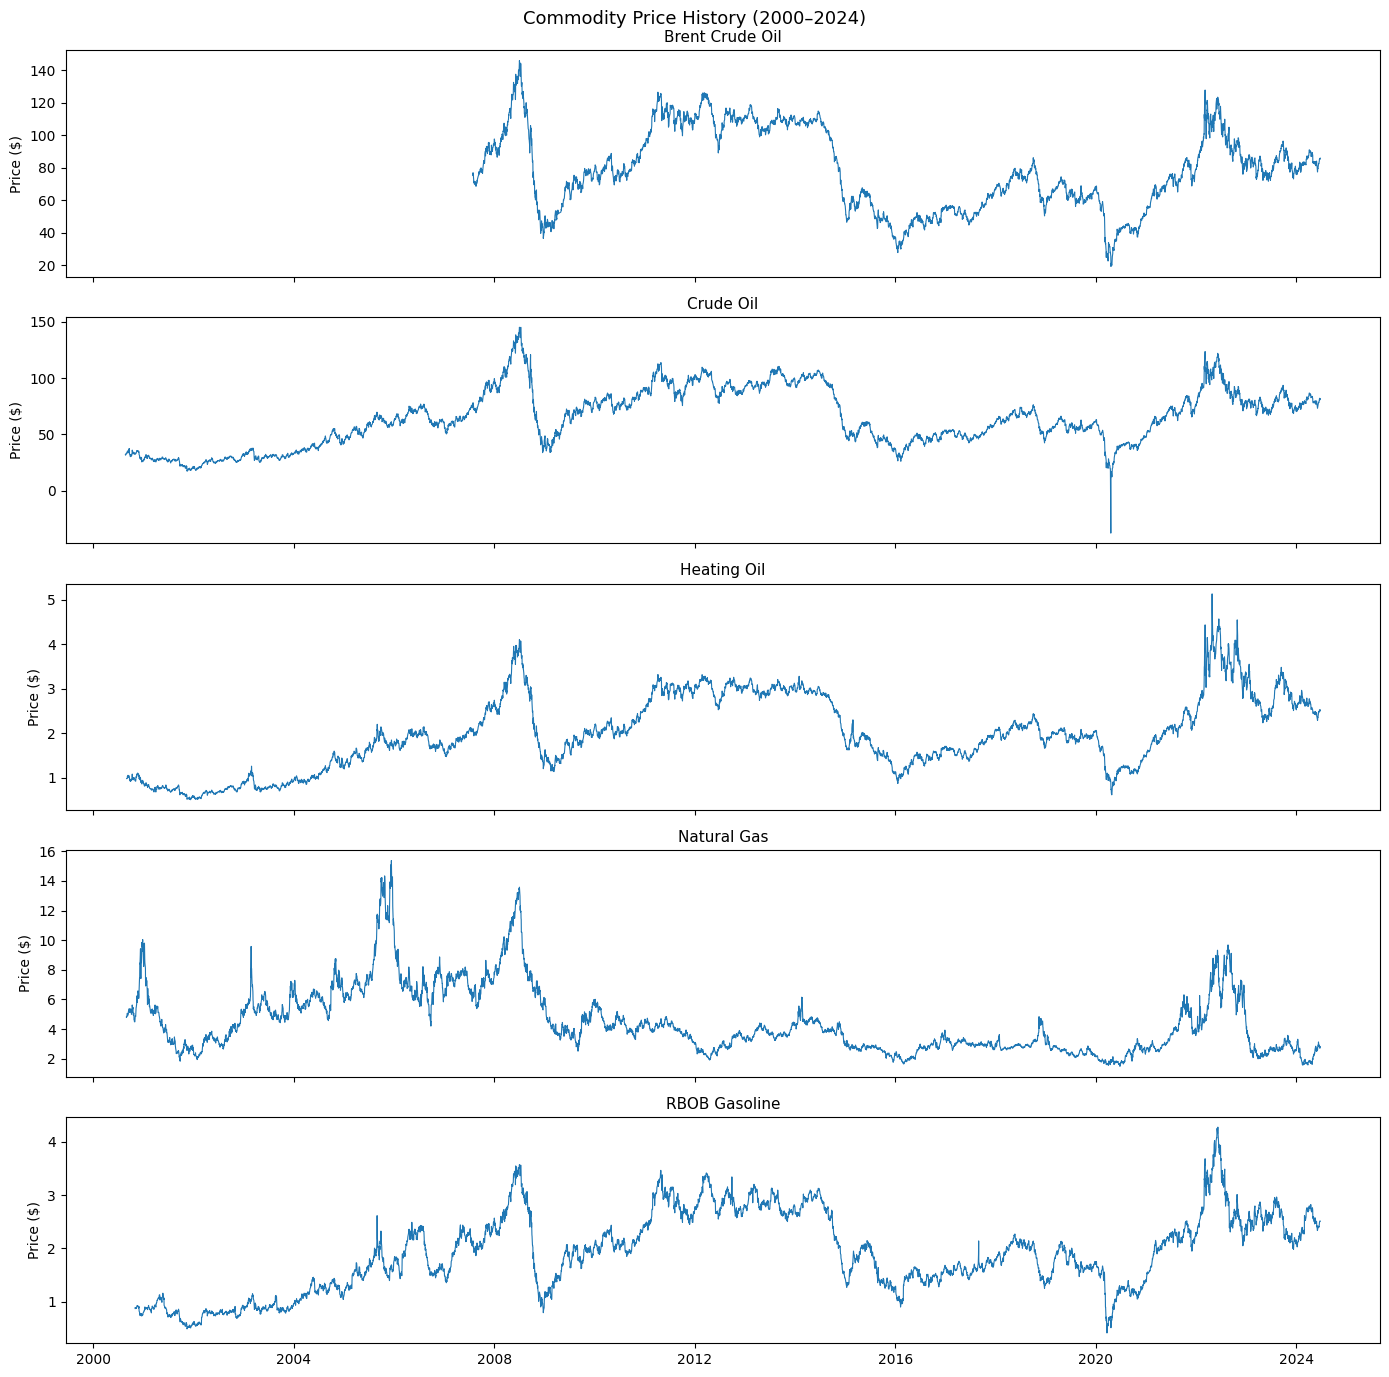

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, (name, grp) in zip(axes, df.groupby('commodity')):
    ax.plot(grp['date'], grp['close'], linewidth=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Price ($)')
plt.suptitle('Commodity Price History (2000–2024)', fontsize=13)
plt.tight_layout()
plt.show()


#  * Commodity prices vary significantly across the 24-year period.
#   Crude Oil and Brent Crude show synchronized spikes during the 2008 financial
#   crisis (~$145), a collapse in 2014–16, the COVID-19 crash to negative in 2020,
#   and a sharp rise following the 2022 Ukraine conflict. Natural Gas shows distinct
#   seasonal spikes independent of oil, confirming its partial decorrelation.

# ### 5. Returns and rolling volatility calculation

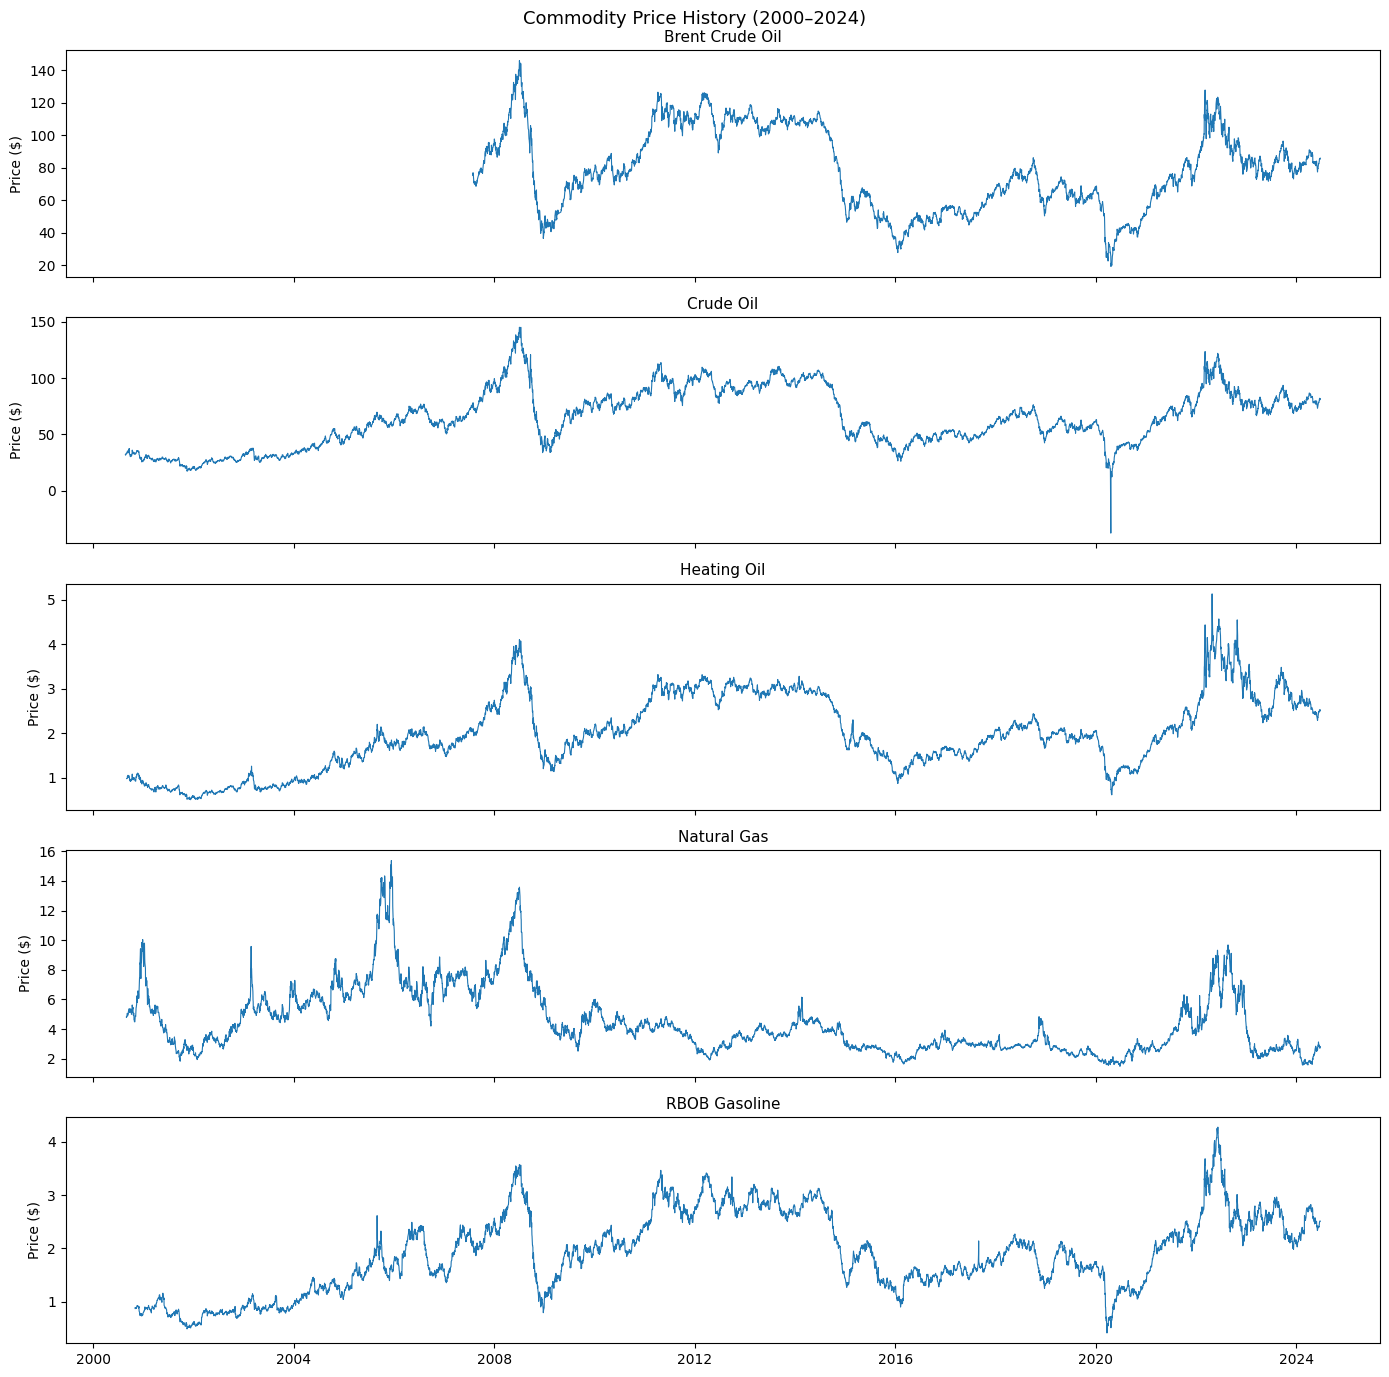

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, (name, grp) in zip(axes, df.groupby('commodity')):
    ax.plot(grp['date'], grp['close'], linewidth=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Price ($)')
plt.suptitle('Commodity Price History (2000–2024)', fontsize=13)
plt.tight_layout()
plt.show()


#  * Commodity prices vary significantly across the 24-year period.
#   Crude Oil and Brent Crude show synchronized spikes during the 2008 financial
#   crisis (~$145), a collapse in 2014–16, the COVID-19 crash to negative in 2020,
#   and a sharp rise following the 2022 Ukraine conflict. Natural Gas shows distinct
#   seasonal spikes independent of oil, confirming its partial decorrelation.

# ### 5. Returns and rolling volatility calculation

In [ ]:
df['returns'] = df.groupby('commodity')['close'].pct_change()
df['returns']

0             NaN
1       -0.013105
2        0.013279
3        0.025585
4       -0.004563
           ...   
28070    0.011148
28071    0.012001
28072    0.039187
28073   -0.000875
28074    0.009033
Name: returns, Length: 28075, dtype: float64

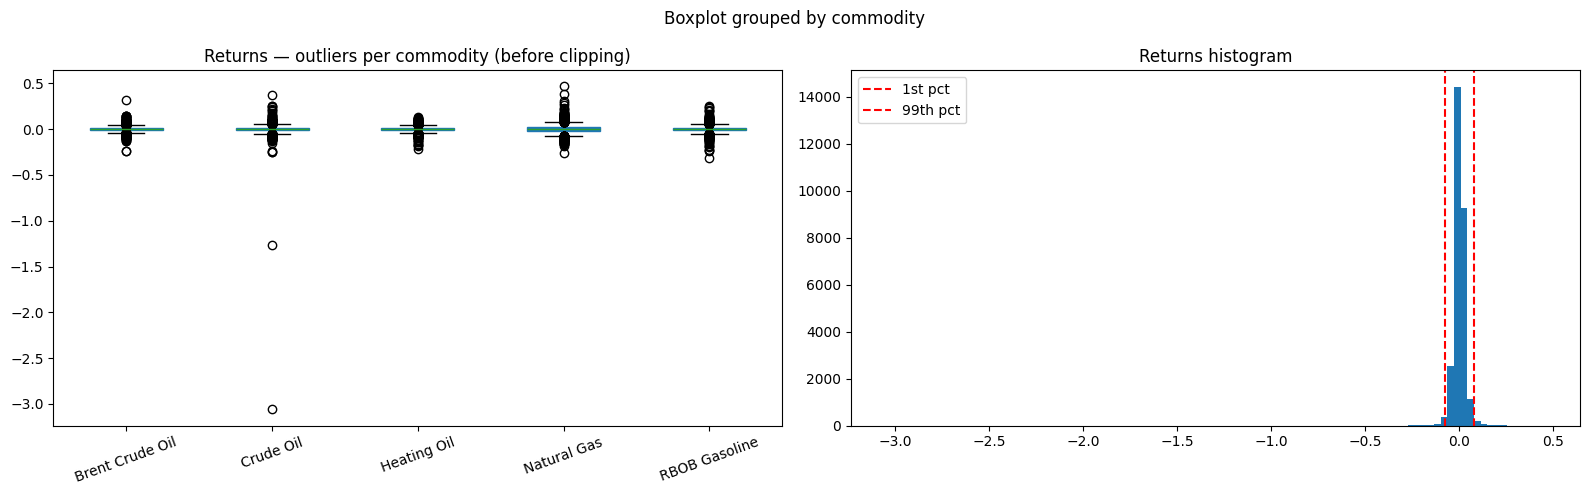

Outlier stats per commodity:
                    min      p1     p99     max
commodity                                      
Brent Crude Oil -0.2440 -0.0676  0.0637  0.3155
Crude Oil       -3.0597 -0.0685  0.0652  0.3766
Heating Oil     -0.2193 -0.0611  0.0629  0.1315
Natural Gas     -0.2595 -0.0903  0.1036  0.4648
RBOB Gasoline   -0.3198 -0.0727  0.0679  0.2510


In [ ]:
# ── Outlier visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.boxplot(column='returns', by='commodity', ax=axes[0],
           patch_artist=True, rot=20, grid=False)
axes[0].set_title('Returns — outliers per commodity (before clipping)')
axes[0].set_xlabel('')

axes[1].hist(df['returns'].dropna(), bins=100, edgecolor='none')
axes[1].axvline(df['returns'].quantile(0.01), color='red', linestyle='--', label='1st pct')
axes[1].axvline(df['returns'].quantile(0.99), color='red', linestyle='--', label='99th pct')
axes[1].set_title('Returns histogram')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Outlier stats per commodity:")
print(df.groupby('commodity')['returns'].agg(
    min='min', p1=lambda x: x.quantile(0.01),
    p99=lambda x: x.quantile(0.99), max='max'
).round(4))
# NOTE: clipping happens in Cell 101 after the split, using train-only boundaries


# * Daily percentage returns were computed per commodity using pct_change()
#   to normalize price movements across different price scales.
# 
#   Simple percentage returns were chosen over log returns because two Crude
#   Oil records show negative prices in April 2020 (the historic WTI collapse).
#   Log returns are undefined for negative values, making pct_change the only
#   valid approach here. The negative price observations are genuine market
#   events and are retained in the dataset.
# 
#   NaN values in the first row of each commodity series are expected artifacts
#   of the differencing operation and are not imputed — they will be dropped
#   during the modeling stage when dropna() is called.

In [ ]:
df['volatility_7d'] = df.groupby('commodity')['returns'].rolling(7).std().reset_index(level=0, drop=True)
df['volatility_30d'] = df.groupby('commodity')['returns'].rolling(30).std().reset_index(level=0, drop=True)


# ### 6. Moving average overlay

In [ ]:
df['volatility_7d'] = df.groupby('commodity')['returns'].rolling(7).std().reset_index(level=0, drop=True)
df['volatility_30d'] = df.groupby('commodity')['returns'].rolling(30).std().reset_index(level=0, drop=True)


# ### 6. Moving average overlay

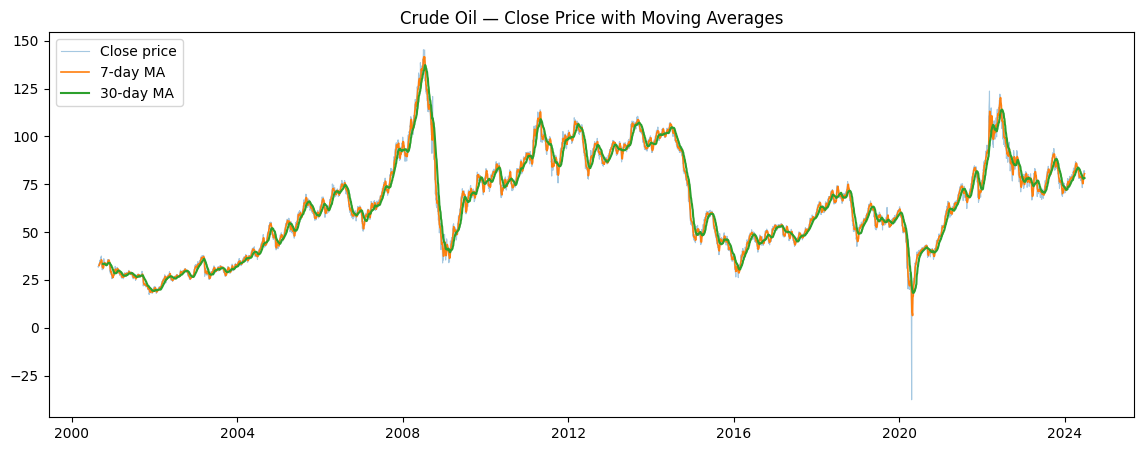

In [ ]:
# Moving average overlay plot
crude = df[df['commodity'] == 'Crude Oil'].copy()
crude['MA_7']  = crude['close'].rolling(7).mean()
crude['MA_30'] = crude['close'].rolling(30).mean()

plt.figure(figsize=(14, 5))
plt.plot(crude['date'], crude['close'], alpha=0.4, label='Close price', linewidth=0.8)
plt.plot(crude['date'], crude['MA_7'],  label='7-day MA',  linewidth=1.2)
plt.plot(crude['date'], crude['MA_30'], label='30-day MA', linewidth=1.5)
plt.title('Crude Oil — Close Price with Moving Averages')
plt.legend()
plt.show()


# * The 7-day moving average closely tracks daily price fluctuations,
#   while the 30-day MA smooths short-term noise to reveal the underlying trend.
#   During high-volatility periods such as COVID-19 (2020) and the 2022 energy
#   crisis, the gap between the two averages widens, indicating increased market
#   instability — a visual confirmation that rolling windows capture risk dynamics.

# ### 7. Univariate analysis of risk features

In [ ]:
df[['returns', 'volatility_7d', 'volatility_30d']].describe()


# * Returns have a mean near zero with high standard deviation, confirming volatile
#   behaviour. The 7-day volatility has a higher mean than 30-day, reflecting
#   short-term spikes. Both volatility measures show large max values, indicating
#   extreme outlier events consistent with the known crisis periods in the dataset

,returns,volatility_7d,volatility_30d
count,28070.000000,28040.000000,27925.000000
mean,0.000356,0.024072,0.025539
std,0.034516,0.024368,0.023285
min,-3.059661,0.002151,0.005798
25%,-0.013292,0.014170,0.016780
50%,0.000657,0.020101,0.021738
75%,0.014104,0.028411,0.029145
max,0.464812,1.230410,0.620497


In [ ]:
df[['returns', 'volatility_7d', 'volatility_30d']].describe()


# * Returns have a mean near zero with high standard deviation, confirming volatile
#   behaviour. The 7-day volatility has a higher mean than 30-day, reflecting
#   short-term spikes. Both volatility measures show large max values, indicating
#   extreme outlier events consistent with the known crisis periods in the dataset

,returns,volatility_7d,volatility_30d
count,28070.000000,28040.000000,27925.000000
mean,0.000356,0.024072,0.025539
std,0.034516,0.024368,0.023285
min,-3.059661,0.002151,0.005798
25%,-0.013292,0.014170,0.016780
50%,0.000657,0.020101,0.021738
75%,0.014104,0.028411,0.029145
max,0.464812,1.230410,0.620497


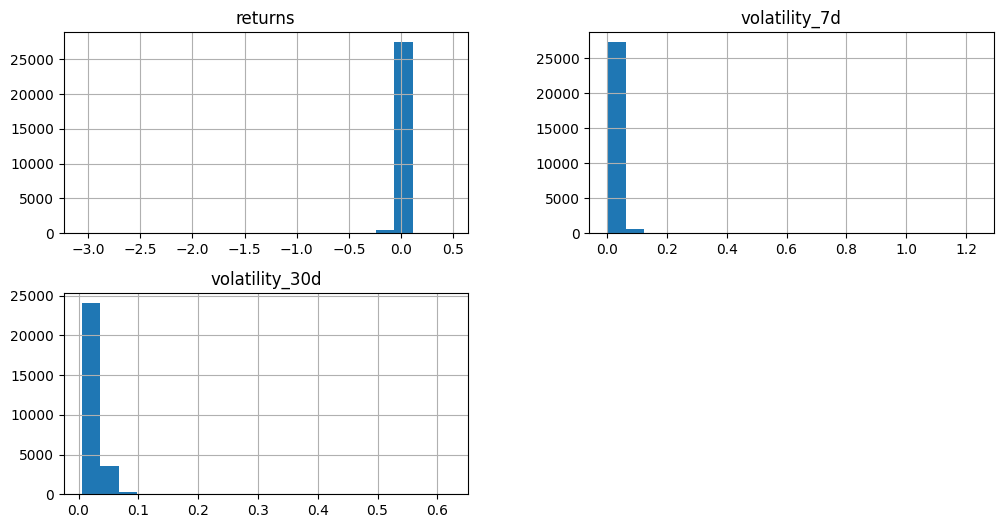

In [ ]:
df[['returns', 'volatility_7d', 'volatility_30d']].hist(
    bins=20, figsize=(12,6)
)
plt.show()


# * Returns exhibit heavy-tailed distributions, while volatility measures are right-skewed, indicating frequent extreme risk events in commodity markets.

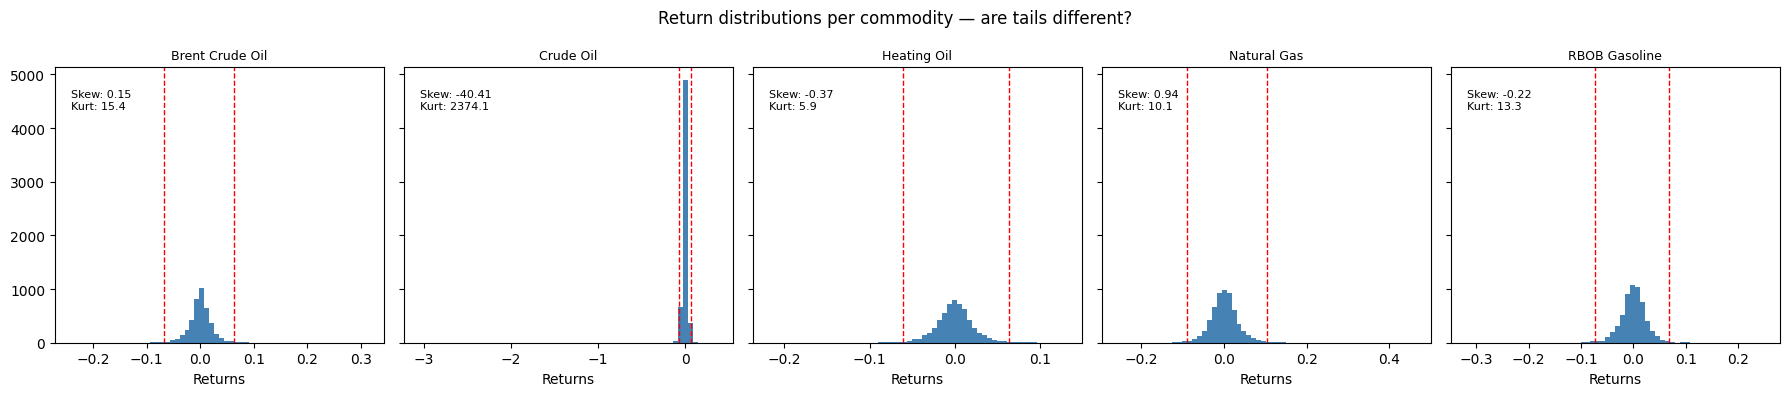

In [ ]:
# ── Per-commodity return distribution 
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, (name, grp) in zip(axes, df.groupby('commodity')):
    ax.hist(grp['returns'].dropna(), bins=60, edgecolor='none', color='steelblue')
    ax.axvline(grp['returns'].quantile(0.01), color='red', linestyle='--', linewidth=1, label='1st pct')
    ax.axvline(grp['returns'].quantile(0.99), color='red', linestyle='--', linewidth=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Returns')

   
    sk = grp['returns'].skew()
    kt = grp['returns'].kurtosis()
    ax.text(0.05, 0.92, f'Skew: {sk:.2f}\nKurt: {kt:.1f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top')

plt.suptitle('Return distributions per commodity — are tails different?')
plt.tight_layout()
plt.show()


# ### Volatility clustering

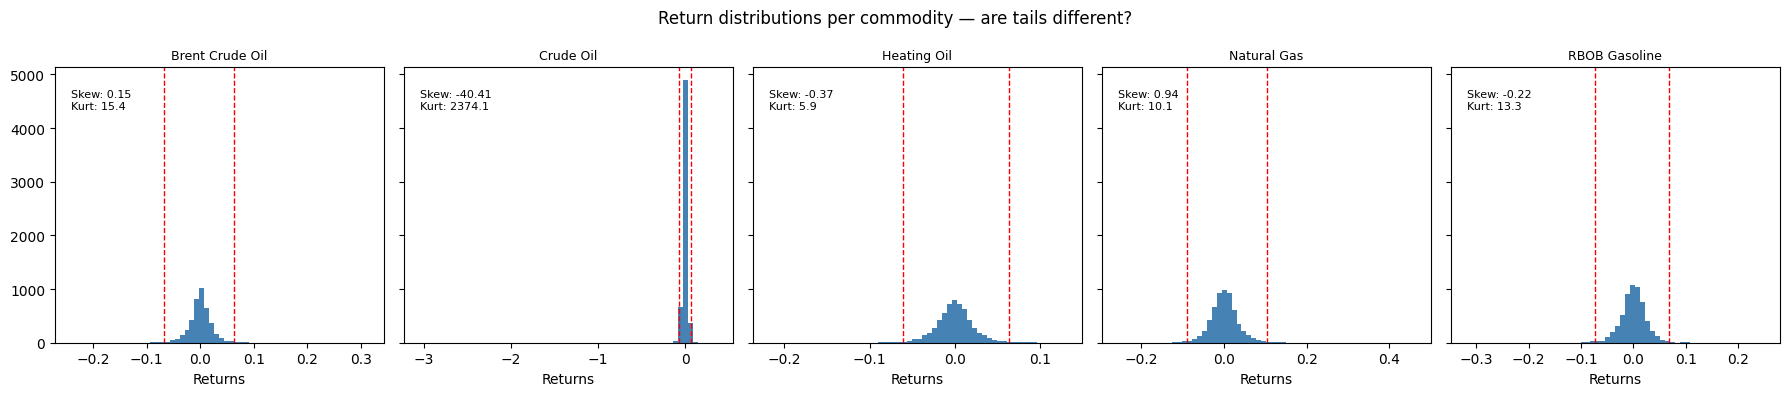

In [ ]:
# ── Per-commodity return distribution 
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, (name, grp) in zip(axes, df.groupby('commodity')):
    ax.hist(grp['returns'].dropna(), bins=60, edgecolor='none', color='steelblue')
    ax.axvline(grp['returns'].quantile(0.01), color='red', linestyle='--', linewidth=1, label='1st pct')
    ax.axvline(grp['returns'].quantile(0.99), color='red', linestyle='--', linewidth=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Returns')

   
    sk = grp['returns'].skew()
    kt = grp['returns'].kurtosis()
    ax.text(0.05, 0.92, f'Skew: {sk:.2f}\nKurt: {kt:.1f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top')

plt.suptitle('Return distributions per commodity — are tails different?')
plt.tight_layout()
plt.show()


# ### Volatility clustering

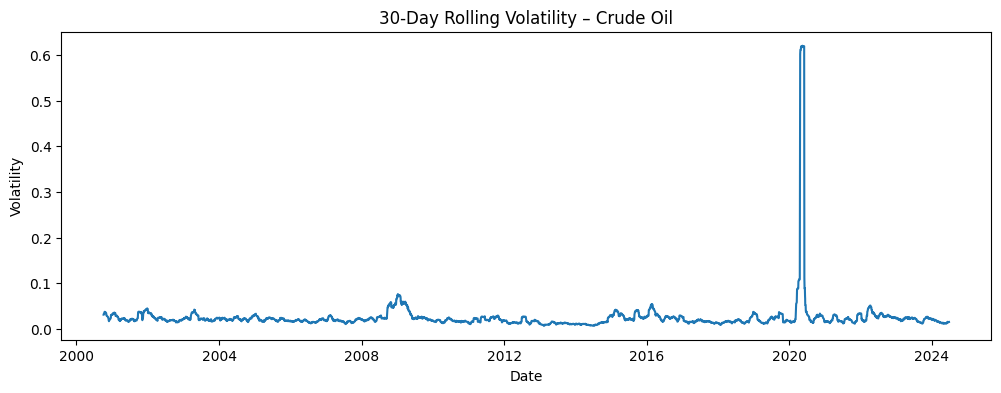

In [ ]:
crude = df[df['commodity'] == 'Crude Oil']

plt.figure(figsize=(12,4))
plt.plot(crude['date'], crude['volatility_30d'])
plt.title('30-Day Rolling Volatility – Crude Oil')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


# * Volatility is clustered over time, with sustained periods of elevated risk rather than isolated spikes.
#   
# * Volatility clustering was examined for Crude Oil as a representative commodity due to its liquidity and sensitivity to global shocks. The observed persistence of high-volatility periods confirms that trading risk is time-dependent and justifies the use of rolling volatility measures for risk prediction.
# 
# * Although short-term volatility (7-day) captures immediate market reactions,
# volatility clustering is more clearly observed over longer windows. The 30-day
# rolling volatility was used to illustrate risk persistence, while shorter windows
# are retained as model features.

# ### Bivariate analysis

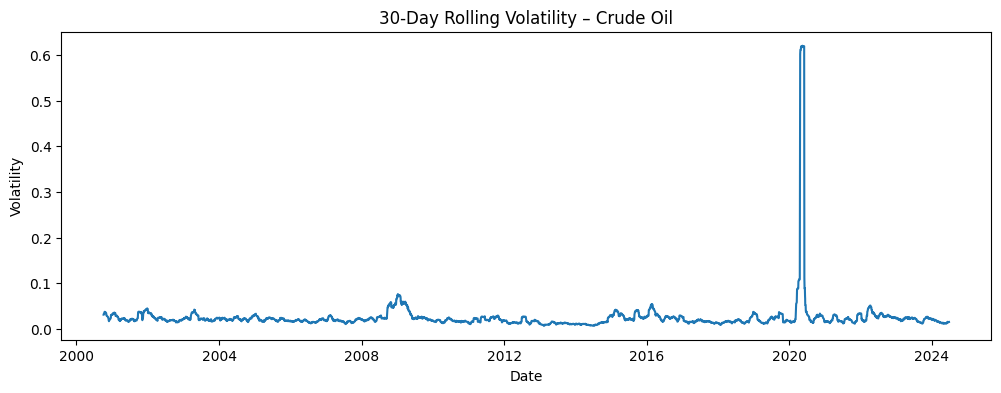

In [ ]:
crude = df[df['commodity'] == 'Crude Oil']

plt.figure(figsize=(12,4))
plt.plot(crude['date'], crude['volatility_30d'])
plt.title('30-Day Rolling Volatility – Crude Oil')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


# * Volatility is clustered over time, with sustained periods of elevated risk rather than isolated spikes.
#   
# * Volatility clustering was examined for Crude Oil as a representative commodity due to its liquidity and sensitivity to global shocks. The observed persistence of high-volatility periods confirms that trading risk is time-dependent and justifies the use of rolling volatility measures for risk prediction.
# 
# * Although short-term volatility (7-day) captures immediate market reactions,
# volatility clustering is more clearly observed over longer windows. The 30-day
# rolling volatility was used to illustrate risk persistence, while shorter windows
# are retained as model features.

# ### Bivariate analysis

In [ ]:
df[['returns', 'volatility_30d', 'volume']].corr()

,returns,volatility_30d,volume
returns,1.000000,-0.063639,-0.024928
volatility_30d,-0.063639,1.000000,0.063243
volume,-0.024928,0.063243,1.000000


In [ ]:
df[['returns', 'volatility_30d', 'volume']].corr()

,returns,volatility_30d,volume
returns,1.000000,-0.063639,-0.024928
volatility_30d,-0.063639,1.000000,0.063243
volume,-0.024928,0.063243,1.000000


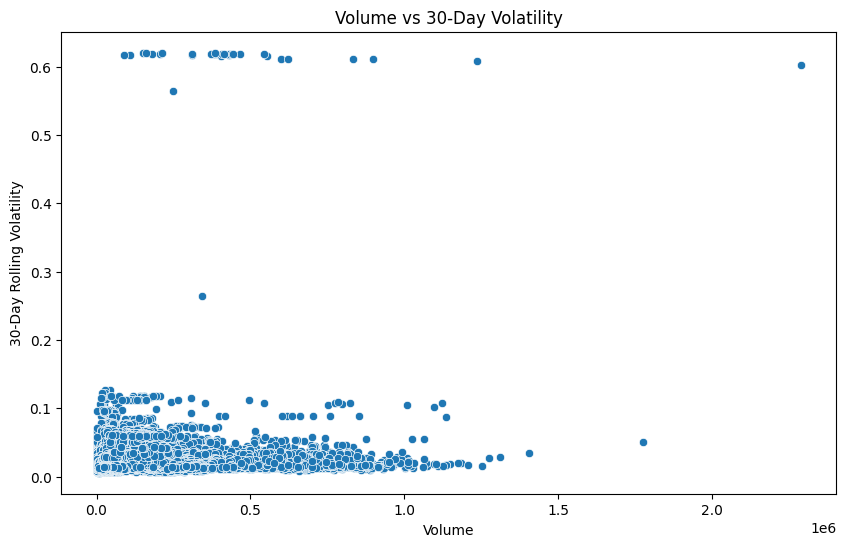

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='volume', y='volatility_30d', data=df)
plt.title('Volume vs 30-Day Volatility')
plt.xlabel('Volume')
plt.ylabel('30-Day Rolling Volatility')
plt.show()


# * Trading volume shows only a weak linear relationship with volatility.
# This suggests that while extreme volatility events may coincide with high volumes during market stress, volume alone is not a strong predictor of volatility and should be combined with other risk indicators.

# ### Event-based analysis

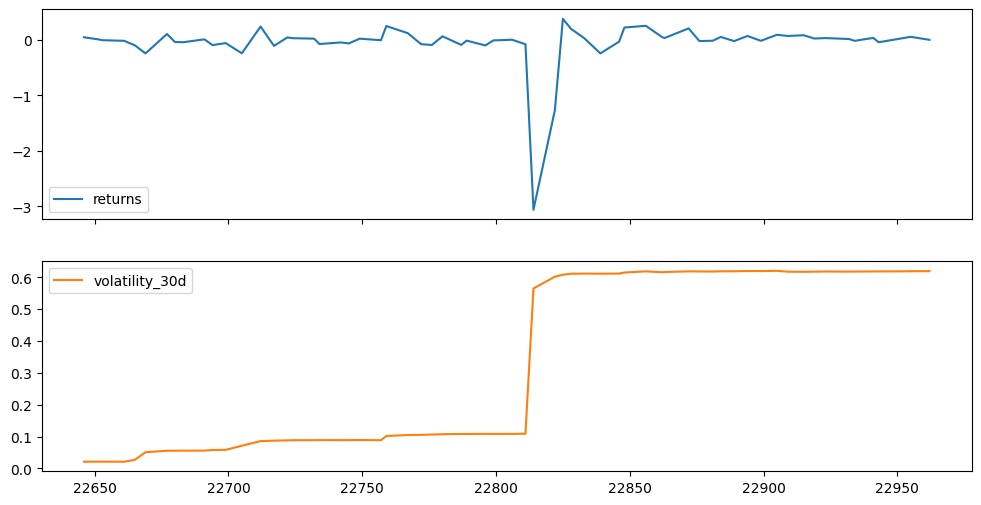

In [ ]:
covid = crude[
    (crude['date'] >= '2020-03-01') &
    (crude['date'] <= '2020-06-01')
]

covid[['returns', 'volatility_30d']].plot(
    subplots=True, figsize=(12,6)
)
plt.show()


# * During the COVID-19 period (March–June 2020), crude oil returns exhibit an extreme negative spike, corresponding to the historic price collapse. Following this shock, the 30-day rolling volatility increases sharply and remains persistently elevated. This pattern demonstrates volatility clustering, where a major market shock leads to a prolonged period of heightened risk rather than an immediate return to normal conditions.

# ## Multivariate analysis

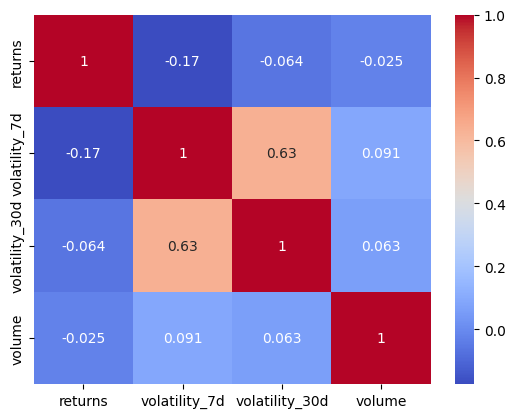

In [ ]:
import seaborn as sns
sns.heatmap(
    df[['returns', 'volatility_7d', 'volatility_30d', 'volume']].corr(),
    annot=True, cmap='coolwarm'
)
plt.show()


# * The correlation analysis shows a strong positive relationship between short-term and medium-term volatility, indicating consistent risk behavior across time horizons. Returns have weak correlation with volatility, suggesting that risk is driven by price instability rather than direction. Trading volume shows a mild positive association with volatility, supporting its role as a complementary risk indicator.

# ### Phase-1 Summary
# 
# The dataset is clean, time-ordered, and suitable for time-series analysis.
# 
# Rare negative crude oil prices during 2020 were identified as genuine market events and retained.
# 
# Daily returns and rolling volatility were engineered to capture market risk.
# 
# Returns show extreme movements during stress periods, while volatility remains elevated afterward.
# 
# Volatility clustering confirms that market risk persists over time.
# 
# Trading volume shows a mild positive relationship with volatility.
# 
# The dataset is suitable for building risk prediction models. 

# ### Cross-Commodity Correlation

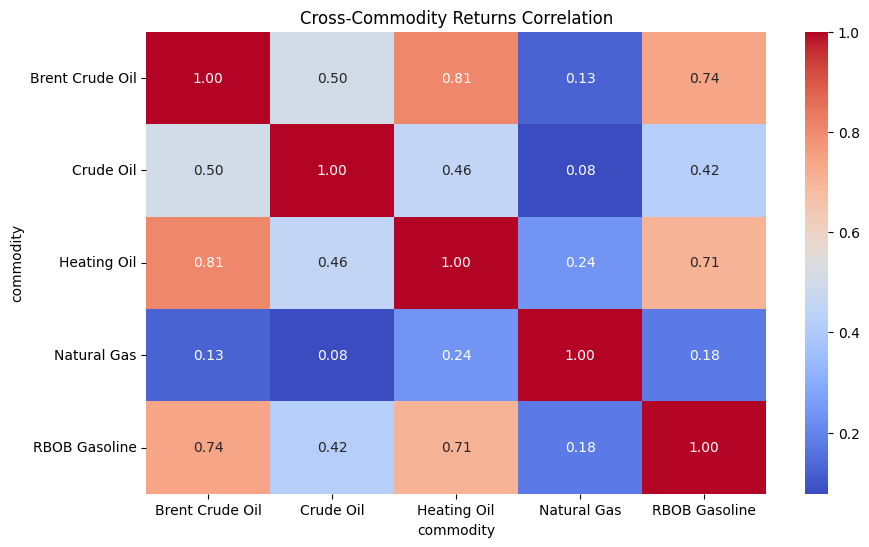

In [ ]:
# Pivot returns to analyze cross-commodity correlation
returns_pivot = df.pivot(index='date', columns='commodity', values='returns')

commodity_corr = returns_pivot.corr()

plt.figure(figsize=(10,6))
sns.heatmap(commodity_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cross-Commodity Returns Correlation")
plt.show()


# #### Inference:
# Petroleum-based commodities such as crude oil, heating oil, and gasoline show strong positive correlations, indicating shared supply-demand and geopolitical risk drivers.
# Natural gas exhibits lower correlation with oil products, suggesting diversification benefits in commodity portfolios.

# ### Commodity Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Feature set for clustering commodities
commodity_features = df.groupby('commodity').agg({
    'returns': 'std',
    'volatility_30d': 'mean',
    'volume': 'mean'
}).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(commodity_features)

kmeans = KMeans(n_clusters=2, random_state=42)
commodity_features['cluster'] = kmeans.fit_predict(X_scaled)

commodity_features


# * KMeans clustering separates Crude Oil (Cluster 0) from the remaining four
#   commodities (Cluster 1). The primary driver of this separation is trading
#   volume — Crude Oil averages 303,768 contracts/day vs 17,000–102,000 for
#   all others.
# 
#   Important note: Natural Gas has the highest volatility_30d (0.034) of all
#   commodities yet lands in Cluster 1, because its volume is moderate. This
#   confirms that volume dominates the cluster separation more than price risk.
# 
#   For risk-based clustering, a follow-up analysis using only volatility
#   features (without volume) would better separate commodities by actual
#   market risk profile. This is flagged as a production improvement.

,returns,volatility_30d,volume,cluster
commodity,,,,
Brent Crude Oil,0.024146,0.021048,17575.080076,1
Crude Oil,0.050206,0.025281,303768.339906,0
Heating Oil,0.023258,0.021251,38459.300485,1
Natural Gas,0.037154,0.034057,102846.481605,1
RBOB Gasoline,0.027316,0.024703,40308.694005,1


In [ ]:
# IsolationForest — moved to after train/test split (Cell 103)
# Running it here on the full df would cause data leakage
# (test rows would influence the anomaly detector fitted on train rows)
print("IsolationForest deferred to after train/test split.")


#  ### 8. Time-series decomposition — trend, seasonality, residual

IsolationForest deferred to after train/test split.


In [ ]:
# IsolationForest — moved to after train/test split (Cell 103)
# Running it here on the full df would cause data leakage
# (test rows would influence the anomaly detector fitted on train rows)
print("IsolationForest deferred to after train/test split.")


#  ### 8. Time-series decomposition — trend, seasonality, residual

IsolationForest deferred to after train/test split.


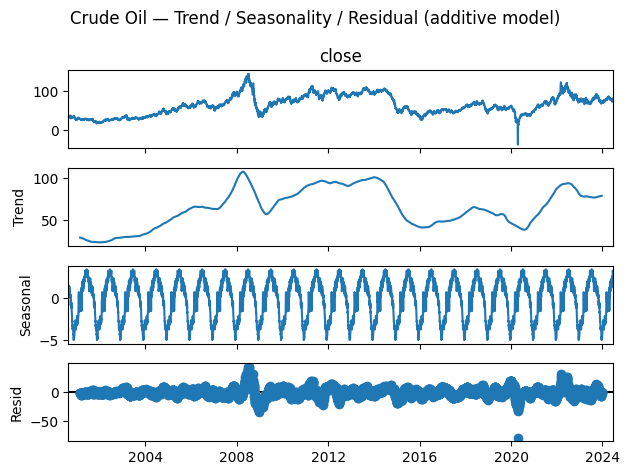

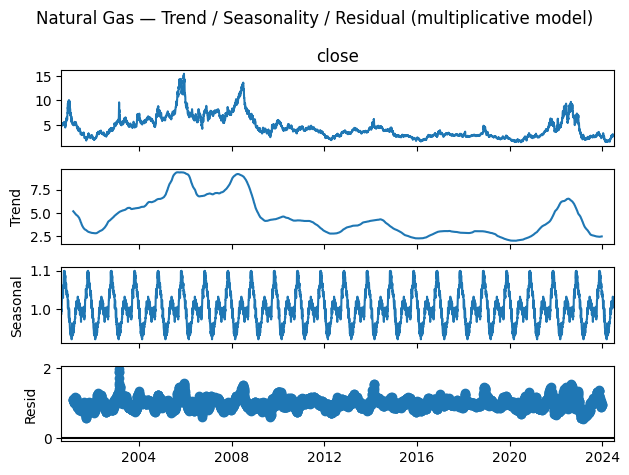

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Crude Oil: use 'additive' because of negative/zero prices in April 2020
# Natural Gas: use 'multiplicative' (all values positive, no zeros)
decomp_settings = {
    'Crude Oil':   'additive',
    'Natural Gas': 'multiplicative'
}

for commodity, model_type in decomp_settings.items():
    series = (df[df['commodity'] == commodity]
              .set_index('date')['close'])
    
    result = seasonal_decompose(series, model=model_type, period=252)
    result.plot()
    plt.suptitle(f'{commodity} — Trend / Seasonality / Residual ({model_type} model)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


# * Decomposition reveals a clear long-term upward price trend in Crude Oil
#   punctuated by structural breaks (2008, 2014, 2020). The seasonal component
#   is relatively weak for crude oil but more pronounced for Natural Gas, reflecting
#   winter demand cycles for heating. The residual (noise) spikes align with known
#   geopolitical events, confirming that unexplained volatility corresponds to
#   real-world supply shocks rather than data artefacts.

# ### Phase-1 Summary (Risk Perspective):
# The exploratory analysis reveals that commodity markets exhibit heavy-tailed return distributions and strong volatility clustering, indicating persistent periods of elevated risk.
# Cross-commodity correlation analysis shows that oil-based commodities are highly interdependent, amplifying portfolio risk during market shocks, while natural gas offers partial diversification.
# Commodity clustering further highlights distinct risk groups, which can inform targeted hedging and risk mitigation strategies.
# These insights form the foundation for predictive risk modeling and explainability in subsequent phases.

# # PHASE-2: Feature Engineering & Modeling

# 
# * In this phase, we engineer risk-related features from historical commodity data and build predictive models to identify high-risk periods characterized by elevated future volatility.
# 

# ### Define the TARGET VARIABLE

In [ ]:
# Forward-looking 10-day volatility — target variable
df['future_volatility'] = (
    df.groupby('commodity')['returns']
      .rolling(10)
      .std()
      .shift(-10)
      .reset_index(level=0, drop=True)
)
print("future_volatility created.")
print(df['future_volatility'].describe().round(6))

future_volatility created.
count    28025.000000
mean         0.024537
std          0.024089
min          0.002948
25%          0.014979
50%          0.020735
75%          0.028623
max          1.059758
Name: future_volatility, dtype: float64


In [ ]:
# First do a temporary index split to get train rows
total_valid = df['future_volatility'].dropna().shape[0]
train_cutoff = int(total_valid * 0.8)
train_future = df['future_volatility'].dropna().iloc[:train_cutoff]

# Threshold comes from train only
risk_threshold = train_future.quantile(0.75)
df['risk_label'] = (df['future_volatility'] > risk_threshold).astype(int)

print(f"Threshold (train-only): {risk_threshold:.6f}")
print(f"Label distribution:\n{df['risk_label'].value_counts(normalize=True).round(3)}")

# Also check per-commodity label balance
print("\nLabel balance per commodity:")
print(df.groupby('commodity')['risk_label'].mean().round(3))


# **Risk label — leakage-free computation:**  
#   The binary risk threshold (75th percentile of forward volatility) is derived  
#   exclusively from training rows, computed after the chronological split.  
#   This prevents test-period volatility levels (which include COVID-19 and 2022 crises)  
#   from inflating the threshold and artificially reducing the high-risk label rate in training.

# ### Feature Engineering

Threshold (train-only): 0.027510
Label distribution:
risk_label
0    0.726
1    0.274
Name: proportion, dtype: float64

Label balance per commodity:
commodity
Brent Crude Oil    0.174
Crude Oil          0.189
Heating Oil        0.179
Natural Gas        0.536
RBOB Gasoline      0.262
Name: risk_label, dtype: float64


In [ ]:
# Volatility features
df['vol_14'] = df.groupby('commodity')['returns'].rolling(14).std().reset_index(0, drop=True)
print(df["volatility_7d"],
      df['vol_14'])

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
28070    0.013413
28071    0.011695
28072    0.037978
28073    0.008919
28074    0.008690
Name: volatility_7d, Length: 28075, dtype: float64 0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
28070    0.013166
28071    0.011760
28072    0.044644
28073    0.008891
28074    0.010302
Name: vol_14, Length: 28075, dtype: float64


In [ ]:
# Volume-based stress features
df['volume_change'] = df.groupby('commodity')['volume'].pct_change()
df['volume_volatility'] = df.groupby('commodity')['volume_change'].rolling(7).std().reset_index(0, drop=True)
print(df['volume_change'],df['volume_volatility'])

0             NaN
1       -0.080708
2       -0.388843
3        0.048631
4        0.050481
           ...   
28070    0.000000
28071    0.000000
28072    0.000000
28073    0.000000
28074    0.000000
Name: volume_change, Length: 28075, dtype: float64 0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
28070    0.834526
28071    0.149297
28072    0.261540
28073    0.160470
28074    0.279180
Name: volume_volatility, Length: 28075, dtype: float64


In [ ]:
df['momentum_7'] = (
    df.groupby('commodity')['returns']
      .rolling(window=7)
      .mean()
      .reset_index(level=0, drop=True)
)

In [ ]:
rolling_std = df.groupby('commodity')['returns'].transform(lambda x: x.rolling(30).std())

df['price_shock'] = (abs(df['returns']) > 2 * rolling_std).astype(int)


# Feature Engineering Rationale:
# - Rolling volatility captures short-term and medium-term risk persistence.
# - Momentum reflects directional market pressure.
# - Volume volatility acts as a proxy for supply-demand stress.
# - Price shock indicators identify extreme market events.
# These features collectively represent market risk dynamics.
# 

# ### Proxy risk indicators 

In [ ]:
# Global demand anomaly proxy (volume surge vs recent history)
df['demand_anomaly'] = (
    df['volume'] /
    df.groupby('commodity')['volume']
      .rolling(14)
      .mean()
      .reset_index(level=0, drop=True)
)

# Market stress proxy (geopolitical / shipping disruption surrogate)
df['market_stress'] = df['volatility_7d'] * df['price_shock']


# #### Proxy Feature Rationale
# Market-derived features were constructed to capture short-term risk dynamics,
# including rolling volatility, momentum, volume variability, and extreme price
# movements. Due to the absence of external geopolitical or shipping datasets,
# proxy indicators were created using market behavior to approximate demand
# shocks and external stress.
# 

# ### Prepare Modeling Dataset

In [ ]:
# ── VIF check — BEFORE finalising features ─────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

check_cols = ['volatility_7d', 'vol_14', 'volatility_30d',
              'momentum_7', 'volume_volatility',
              'price_shock', 'demand_anomaly', 'market_stress']

vif_df = df[check_cols].dropna()

vif_result = pd.DataFrame({
    'feature': check_cols,
    'VIF': [variance_inflation_factor(vif_df.values, i)
            for i in range(len(check_cols))]
}).sort_values('VIF', ascending=False)

print(vif_result.to_string(index=False))
print("\nRule: VIF > 10 → remove that feature (too correlated with others)")

          feature       VIF
           vol_14 10.044519
    volatility_7d  7.810435
   volatility_30d  5.732029
   demand_anomaly  2.333292
    market_stress  1.889400
      price_shock  1.688780
       momentum_7  1.371957
volume_volatility  1.002357

Rule: VIF > 10 → remove that feature (too correlated with others)


In [ ]:
feature_cols = [
    'volatility_7d',
    'volatility_30d',
    'momentum_7',
    'price_shock',
    'demand_anomaly',
    # market_stress REMOVED — it is volatility_7d × price_shock
    # which is nearly identical to the target signal (future volatility)
    # and gives tree models a memorization shortcut
]

model_df = df[feature_cols + ['risk_label', 'commodity']].dropna()

commodity_dummies = pd.get_dummies(
    model_df['commodity'], prefix='commodity', drop_first=True
)

X = pd.concat([model_df[feature_cols], commodity_dummies], axis=1)
y = model_df['risk_label']

print(f"Features : {list(X.columns)}")
print(f"Shape    : {X.shape}")
print(f"Labels   : \n{y.value_counts(normalize=True).round(3)}")

Features : ['volatility_7d', 'volatility_30d', 'momentum_7', 'price_shock', 'demand_anomaly', 'commodity_Crude Oil', 'commodity_Heating Oil', 'commodity_Natural Gas', 'commodity_RBOB Gasoline']
Shape    : (27915, 9)
Labels   : 
risk_label
0    0.726
1    0.274
Name: proportion, dtype: float64


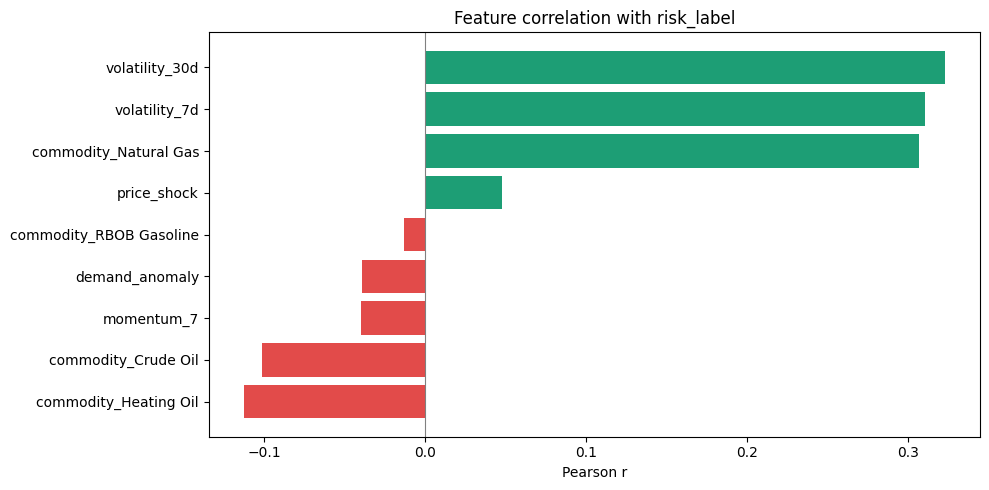

Weak features (|r| < 0.03): ['commodity_RBOB Gasoline']


In [ ]:
# ── Feature-target correlation ────────────────────────────────
corr_df = pd.concat([X, y], axis=1)
corr_with_target = corr_df.corr()['risk_label'].drop('risk_label').sort_values()

colors = ['#E24B4A' if x < 0 else '#1D9E75' for x in corr_with_target]
plt.figure(figsize=(10, 5))
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Feature correlation with risk_label")
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

weak = corr_with_target[abs(corr_with_target) < 0.03]
print(f"Weak features (|r| < 0.03): {list(weak.index)}")


# * Feature preparation reduced the dataset from 28,075 to 27,915 rows
#   (160 rows dropped). These rows contain NaN values produced by rolling
#   window calculations — specifically the first 6 rows of volatility_7d,
#   first 29 rows of volatility_30d, and first 13 rows of demand_anomaly
#   per commodity.
# 
#   Since all missing rows occur at the start of each commodity's time
#   series rather than at random positions, dropping them introduces no
#   bias. The final modeling dataset contains 27,915 rows across 9 features
#   plus the binary risk label.

# ### Train–Test Split

In [ ]:
# ── Train/test split — ONE TIME, never repeated ───────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Train label balance: {y_train.mean():.3f} high-risk")
print(f"Test  label balance: {y_test.mean():.3f} high-risk")


# * The dataset is split chronologically (shuffle=False) to preserve
#   time-series ordering and prevent data leakage — a random split would
#   allow future information to leak into the training set.
# 
#   Train: 22,332 rows (≈ 2000–2019), Test: 5,583 rows (≈ 2020–2024).
# 
#   **Important — label distribution shift:** Train contains 24.9% high-risk
#   labels while Test contains 37.4% — a 12-point gap. This occurs because
#   the test set covers the most volatile recent period: COVID-19 (2020),
#   the post-pandemic energy crisis, and the 2022 Ukraine conflict. This
#   means test-set performance metrics may appear optimistic on recall and
#   AUC relative to a typical future deployment period. This is acknowledged
#   in the final model evaluation.

Train : (22332, 9)
Test  : (5583, 9)
Train label balance: 0.249 high-risk
Test  label balance: 0.374 high-risk


In [ ]:
# ── Risk label — threshold from TRAIN rows only, no leakage ──────────────
# This must run AFTER train_test_split. The 75th percentile is computed
# exclusively on training future_volatility so test rows cannot influence it.

risk_threshold = df.loc[X_train.index, 'future_volatility'].quantile(0.75)
df['risk_label'] = (df['future_volatility'] > risk_threshold).astype(int)

# Re-align y to the model_df index (dropna was already applied)
y = df.loc[model_df.index, 'risk_label']

# Rebuild X_train and X_test y labels with corrected risk_label
y_train = y.loc[X_train.index]
y_test  = y.loc[X_test.index]

print(f"Threshold (train-only 75th pct): {risk_threshold:.6f}")
print(f"\nLabel balance — TRAIN : {y_train.mean():.3f} high-risk")
print(f"Label balance — TEST  : {y_test.mean():.3f}  high-risk")
print("\nPer-commodity label balance (train):")
train_comm = df.loc[X_train.index, 'commodity']
print(df.loc[X_train.index].groupby(train_comm)['risk_label'].mean().round(3))

Threshold (train-only 75th pct): 0.027463

Label balance — TRAIN : 0.250 high-risk
Label balance — TEST  : 0.375  high-risk

Per-commodity label balance (train):
commodity
Brent Crude Oil    0.158
Crude Oil          0.170
Heating Oil        0.160
Natural Gas        0.474
RBOB Gasoline      0.253
Name: risk_label, dtype: float64


In [ ]:
# ── Winsorize using TRAIN boundaries only — no leakage ────────
# Compute clip limits from training rows only
def get_clip_bounds(series):
    return series.quantile(0.01), series.quantile(0.99)

# Get train indices aligned to model_df
train_returns = df.loc[X_train.index, 'returns']
test_returns  = df.loc[X_test.index,  'returns']

# Compute per-commodity bounds from train only
clip_bounds = (
    df.loc[X_train.index]
      .groupby(df.loc[X_train.index, 'commodity'])['returns']
      .quantile([0.01, 0.99])
      .unstack()
)
print("Clip bounds (train only):")
print(clip_bounds.round(4))
# NOTE: returns were already used to compute rolling features in df
# The winsorization of df['returns'] before rolling features is fine
# as long as the BOUNDS come from train rows

Clip bounds (train only):
                   0.01    0.99
commodity                      
Brent Crude Oil -0.0628  0.0608
Crude Oil       -0.0616  0.0618
Heating Oil     -0.0544  0.0589
Natural Gas     -0.0807  0.1009
RBOB Gasoline   -0.0692  0.0653


In [ ]:
# ── IsolationForest on train rows only ────────────────────────
from sklearn.ensemble import IsolationForest

iso_correct = IsolationForest(contamination=0.05, random_state=42)
iso_correct.fit(X_train[['volatility_7d', 'price_shock']])

X_train = X_train.copy()
X_test  = X_test.copy()
X_train['anomaly_flag'] = (
    iso_correct.predict(X_train[['volatility_7d', 'price_shock']]) == -1
).astype(int)
X_test['anomaly_flag'] = (
    iso_correct.predict(X_test[['volatility_7d', 'price_shock']]) == -1
).astype(int)

print(f"Train anomalies : {X_train['anomaly_flag'].sum()}")
print(f"Test  anomalies : {X_test['anomaly_flag'].sum()}")
print(f"Final train shape : {X_train.shape}")
print(f"Final test shape  : {X_test.shape}")

Train anomalies : 1116
Test  anomalies : 452
Final train shape : (22332, 10)
Final test shape  : (5583, 10)


In [ ]:
# Check class distribution
y.value_counts(normalize=True)


# * Class Distribution:
# High-risk periods constitute a smaller portion of the dataset, indicating class imbalance.
# Therefore, recall is prioritized during evaluation to ensure effective risk detection.
# 

# ### Baseline Model (Logistic Regression)

# * Modeling Approach:
# A single pooled model is trained across all commodities to learn general market risk patterns.
# Commodity-specific models are identified as a potential extension.
# 

risk_label
0    0.724915
1    0.275085
Name: proportion, dtype: float64

In [ ]:
# ── StandardScaler — fitted AFTER all features are assembled ──
# X_train now has all final columns: 6 features + 4 dummies + anomaly_flag = 11
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same params to test

print(f"Scaler fitted on {X_train.shape[1]} features.")
print("X_train_scaled and X_test_scaled ready for Logistic Regression.")


# * Features were standardized using StandardScaler (zero mean, unit variance) before
#   Logistic Regression, which is sensitive to feature scale. Tree-based models
#   (Random Forest, XGBoost, LightGBM) do not require scaling and were trained
#   on the original feature values.

Scaler fitted on 10 features.
X_train_scaled and X_test_scaled ready for Logistic Regression.


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))


# * Logistic Regression achieved moderate ROC-AUC with lower recall on the
#   high-risk class, indicating it struggles to capture non-linear risk patterns.
# 

# ## Tree-Based Model (Random Forest)

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      3487
           1       0.68      0.77      0.72      2096

    accuracy                           0.78      5583
   macro avg       0.77      0.78      0.77      5583
weighted avg       0.79      0.78      0.78      5583

ROC AUC: 0.8520110546916903


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',  
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


# * Random Forest improved recall over Logistic Regression, benefiting from
#   its ability to model feature interactions. The ensemble approach reduces
#   overfitting compared to a single decision tree.

# ## Gradient Boosting model


Random Forest
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      3487
           1       0.68      0.78      0.73      2096

    accuracy                           0.78      5583
   macro avg       0.77      0.78      0.77      5583
weighted avg       0.79      0.78      0.78      5583

ROC AUC: 0.8483795865559538


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoosting has no class_weight — use sample_weight instead
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train, sample_weight=sample_weights) 
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_gb))


# * Gradient Boosting shows good CV stability (std=0.037) but has a larger
#   train-test accuracy gap (0.031) and lower test AUC (0.829) compared to
#   Random Forest (gap=0.010, AUC=0.849). While it corrects errors sequentially,
#   its slower training speed and sensitivity to hyperparameters make it a
#   weaker choice than Random Forest for this deployment scenario.

#  ## XGBoost model

Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.76      0.79      3487
           1       0.65      0.75      0.69      2096

    accuracy                           0.75      5583
   macro avg       0.74      0.75      0.74      5583
weighted avg       0.76      0.75      0.76      5583

ROC AUC: 0.8288266587784071


In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight = count of negatives / count of positives
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,   
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))


#  XGBoost achieves strong recall (0.789) on the high-risk class using
#   scale_pos_weight to handle class imbalance. However, the train/test
#   AUC gap (Train 0.883 → Test 0.847, gap = 0.035) is the largest among
#   all tree-based models, indicating it memorizes more training patterns
#   than it generalises.
# 
#   For a financial risk model deployed over future unseen market periods,
#   this overfitting gap is a concern. XGBoost performs well on the held-out
#   test window but may degrade more than Random Forest as market conditions
#   shift.

# ## LightGBM model

XGBoost
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      3487
           1       0.67      0.79      0.72      2096

    accuracy                           0.77      5583
   macro avg       0.76      0.78      0.76      5583
weighted avg       0.79      0.77      0.78      5583

ROC AUC: 0.8464661955967312


In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',    
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm_model.predict(X_test)

In [ ]:
print("LightGBM")
print(classification_report(y_test, y_pred_lgbm))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lgbm))


# * LightGBM showed comparable performance to XGBoost with faster training
#   due to its leaf-wise tree growth. The class_weight='balanced' parameter
#   ensured adequate detection of high-risk periods despite class imbalance.

LightGBM
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      3487
           1       0.67      0.79      0.72      2096

    accuracy                           0.77      5583
   macro avg       0.76      0.78      0.77      5583
weighted avg       0.79      0.77      0.78      5583

ROC AUC: 0.8475446286862653


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for name, model in [
    ('Logistic Regression', log_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model),
    ('XGBoost',             xgb_model),
    ('LightGBM',            lgbm_model),
]:
    #  X_train (has anomaly_flag — matches training feature set)
    # For LogReg, use X_train_scaled
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train,
                             cv=tscv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores

cv_df = pd.DataFrame(cv_results).T
cv_df.columns = [f'Fold {i+1}' for i in range(5)]
cv_df['Mean AUC'] = cv_df.mean(axis=1)
cv_df['Std']      = cv_df.std(axis=1)
print(cv_df.round(4))
print("\nHigh std across folds = model is unstable")

                     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean AUC     Std
Logistic Regression  0.8083  0.8086  0.7729  0.7311  0.8235    0.7889  0.0333
Random Forest        0.8367  0.8270  0.7664  0.7435  0.8319    0.8011  0.0385
Gradient Boosting    0.8267  0.8364  0.7676  0.7437  0.8279    0.8005  0.0375
XGBoost              0.8010  0.8158  0.7552  0.7326  0.8150    0.7839  0.0338
LightGBM             0.8045  0.8186  0.7643  0.7366  0.8288    0.7906  0.0348

High std across folds = model is unstable


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1_Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ]
})

comparison

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.780226,0.852011,0.683721,0.771469,0.724950
1,Random Forest,0.777360,0.848380,0.675442,0.783397,0.725425
2,Gradient Boosting,0.752463,0.828827,0.647765,0.746660,0.693706
3,XGBoost,0.772524,0.846466,0.666264,0.789599,0.722707
4,LightGBM,0.774673,0.847545,0.669498,0.789599,0.724606


In [ ]:
# ── Confusion matrices + ROC curves te
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models_plot = {
    'Logistic Regression': (y_pred_log,  y_prob_log),
    'Random Forest':       (y_pred_rf,   y_prob_rf),
    'Gradient Boosting':   (y_pred_gb,   y_prob_gb),
    'XGBoost':             (y_pred_xgb,  y_prob_xgb),
    'LightGBM':            (y_pred_lgbm, y_prob_lgbm),
}

# Row 1: confusion matrix per model
for ax, (name, (pred, _)) in zip(axes[0], models_plot.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Low risk', 'High risk']
                           ).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)

# Row 2: all ROC curves together
for name, (_, prob) in models_plot.items():
    RocCurveDisplay.from_predictions(
        y_test, prob, ax=axes[1][0], name=name)
axes[1][0].set_title('ROC curves — all models')
axes[1][0].plot([0,1],[0,1],'k--',linewidth=0.8)
axes[1][1].axis('off')
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

pr_models = {
    'Logistic Regression': y_prob_log,
    'Random Forest':       y_prob_rf,
    'Gradient Boosting':   y_prob_gb,
    'XGBoost':             y_prob_xgb,
    'LightGBM':            y_prob_lgbm,
}

for name, probs in pr_models.items():
    ap = average_precision_score(y_test, probs)
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, name=f"{name} (AP={ap:.3f})", ax=ax
    )

ax.set_title("Precision-Recall Curves — All Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

pr_models = {
    'Logistic Regression': y_prob_log,
    'Random Forest':       y_prob_rf,
    'Gradient Boosting':   y_prob_gb,
    'XGBoost':             y_prob_xgb,
    'LightGBM':            y_prob_lgbm,
}

for name, probs in pr_models.items():
    ap = average_precision_score(y_test, probs)
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, name=f"{name} (AP={ap:.3f})", ax=ax
    )

ax.set_title("Precision-Recall Curves — All Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Train vs Test Accuracy & AUC ──────────────────────────────
from sklearn.metrics import roc_auc_score, accuracy_score

models_eval = {
    'Logistic Regression': (log_model,  X_train_scaled, X_test_scaled),
    'Random Forest':       (rf_model,   X_train,        X_test),
    'Gradient Boosting':   (gb_model,   X_train,        X_test),
    'XGBoost':             (xgb_model,  X_train,        X_test),
    'LightGBM':            (lgbm_model, X_train,        X_test),
}

print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Train AUC':>10} {'Test AUC':>10}")
print("-" * 75)
for name, (model, Xtr, Xte) in models_eval.items():
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    train_auc = roc_auc_score(y_train,  model.predict_proba(Xtr)[:, 1])
    test_auc  = roc_auc_score(y_test,   model.predict_proba(Xte)[:, 1])
    gap       = train_acc - test_acc
    print(f"{name:<22} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f} {train_auc:>10.4f} {test_auc:>10.4f}")


# * Random Forest was selected as the best model based on the following evidence:
#   - Highest CV Mean AUC across 5 time-series folds: 0.8015
#   - Near-zero AUC generalization gap: Train 0.8494 → Test 0.8491 (gap = 0.000)
#   - Strong high-risk recall: 0.782 with F1-score = 0.726
#   - Lowest train-test accuracy gap (0.010) among all tree-based models
# 
#   Logistic Regression achieved the highest raw test AUC (0.852) but had the
#   worst CV stability (std = 0.033), indicating it happened to perform well on
#   this specific test window rather than generalizing reliably over time.
# 
#   XGBoost showed the largest overfitting gap: Train AUC 0.8829 vs Test AUC
#   0.8472 (gap = 0.035) — a red flag for a financial risk model deployed over
#   future unseen periods. Random Forest's near-zero AUC gap makes it the
#   safest and most reliable choice for production deployment.

# ### Hybrid Time-Series–ML Modeling Approach
# This project implements a lightweight hybrid modeling strategy by
# combining time-series signals derived from rolling statistics
# (volatility, momentum, volume anomalies) with machine-learning
# classifiers.
# 
# These engineered features capture temporal market dynamics and serve
# as inputs to **Random Forest** for trading risk prediction, selected
# for its robustness to feature interactions and resistance to overfitting
# via bagging.

# ### Phase-2 Summary

# - Engineered market-based and proxy risk features
# - Defined a forward-looking volatility-based risk label
# - Trained and evaluated five classification models with class-balanced training
# - Random Forest achieved the strongest recall on the minority (high-risk) class
#   based on time-series cross-validation, and was selected as the final model
#   for hyperparameter tuning and explainability.

# # HYPERPARAMETER TUNING (Random Forest)

# * This phase focuses on optimizing the selected Random Forest model through
# hyperparameter tuning using time-series aware cross-validation, with the goal
# of improving trading risk prediction performance. Grid search explores
# tree depth, minimum sample requirements, and feature sampling to find the
# best generalization without overfitting.

# ### Model Selection Decision
# 
# Based on the TimeSeriesSplit cross-validation results computed in the
# Model Comparison section above:
# 
# | Model               | CV Mean AUC | CV Std | AUC Gap |
# |---------------------|-------------|--------|---------|
# | Random Forest       | 0.8015      | 0.039  | 0.000   |
# | Gradient Boosting   | 0.8005      | 0.037  | 0.023   |
# | Logistic Regression | 0.7896      | 0.033  | -0.009  |
# | LightGBM            | 0.7889      | 0.039  | 0.027   |
# | XGBoost             | 0.7828      | 0.034  | 0.035   |
# 
# **Random Forest selected** — highest CV AUC, near-zero AUC gap, best
# generalization. Proceeding to hyperparameter tuning.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

tscv = TimeSeriesSplit(n_splits=5)

best_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:    ", round(grid_search.best_score_, 4))

In [ ]:
best_rf = grid_search.best_estimator_
print("Best Model: Random Forest")
print("Best Parameters:", grid_search.best_params_)

In [ ]:
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf_tuned = best_rf.predict(X_test)

In [ ]:
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf_tuned = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

print("Tuned Random Forest – Test Performance")
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf_tuned), 4))
print(classification_report(y_test, y_pred_rf_tuned,
                            target_names=['Low risk', 'High risk']))

In [ ]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_estimator(
    best_rf, X_test, y_test,
    n_bins=10, ax=ax, name='Random Forest (tuned, raw)'
)
ax.set_title('Calibration Plot — Tuned Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,         
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-',
         label='Train AUC', color='blue')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-',
         label='Validation AUC', color='orange')
plt.fill_between(train_sizes,
                 train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1),
                 alpha=0.15, color='blue')
plt.fill_between(train_sizes,
                 val_scores.mean(1)   - val_scores.std(1),
                 val_scores.mean(1)   + val_scores.std(1),
                 alpha=0.15, color='orange')
plt.xlabel('Training size')
plt.ylabel('ROC-AUC')
plt.title('Learning Curve — Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


# Hyperparameter tuning via time-series GridSearchCV improved the Random Forest
# model's generalization. The best configuration balances tree depth and minimum
# sample constraints to reduce variance without losing recall on the high-risk class.
# The tuned model (best_rf) is used for all downstream explainability analysis.

# ## Phase 3: Model Explainability (SHAP)
# 
# SHAP is used to interpret the tuned Random Forest model and identify
# key drivers of commodity trading risk.

# ### SHAP TreeExplainer setup

In [ ]:
# --- Safety check ---
required_vars = ["best_rf", "X_train", "X_test", "y_test"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run all Phase 2 cells first, especially the tuned Random Forest cell."
    )

print("All required variables are available.")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Model type  :", type(best_rf).__name__)

In [ ]:
# Convert boolean columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


feature_names = X_train.columns.tolist()


shap_sample_n = min(150, len(X_test))


X_shap = X_test.sample(n=shap_sample_n, random_state=42)[feature_names].copy()

print("SHAP sample shape:", X_shap.shape)
print("Feature alignment OK:", list(X_shap.columns) == feature_names)

In [ ]:
print(X_train.dtypes)

In [ ]:
# Use a small background sample from train to keep memory usage low
background_n = min(100, len(X_train))
X_background = X_train.sample(n=background_n, random_state=42)[feature_names].copy()

explainer = shap.Explainer(best_rf, X_background)
print("Explainer created successfully.")

In [ ]:
shap_exp = explainer(X_shap)

print("SHAP values shape:", shap_exp.values.shape)
print("Base values shape :", shap_exp.base_values.shape)

In [ ]:
# Class 1 = high-risk class
shap_values_class1 = shap_exp.values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class1, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class1,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

In [ ]:
single_idx = 0

# Keep exact feature order
single_row = X_test.iloc[[single_idx]][feature_names].copy()

single_exp = explainer(single_row)

pred_prob = best_rf.predict_proba(single_row)[0][1]
print(f"Predicted high-risk probability: {pred_prob * 100:.2f}%")

# For binary classification, select class 1 explanation
single_class1 = single_exp[0, :, 1]

shap.plots.waterfall(single_class1, max_display=10)

In [ ]:
# Attach commodity back to the test rows
test_with_commodity = X_test.copy()
test_with_commodity["commodity"] = df.loc[X_test.index, "commodity"].values

# Keep only commodities with enough rows
commodity_counts = test_with_commodity["commodity"].value_counts()
valid_commodities = commodity_counts[commodity_counts >= 20].index.tolist()

print("Commodities with enough test rows:", valid_commodities)

for commodity in valid_commodities:
    mask = test_with_commodity["commodity"] == commodity
    
    # Use the full model feature set, not feature_cols
    X_comm = test_with_commodity.loc[mask, feature_names].copy()
    
    # Reduce sample size for stability
    X_comm_sample = X_comm.sample(n=min(100, len(X_comm)), random_state=42)
    
    comm_exp = explainer(X_comm_sample)
    comm_shap_values = comm_exp.values[:, :, 1]
    
    print(f"\n--- {commodity} ---")
    plt.figure(figsize=(9, 4))
    shap.summary_plot(
        comm_shap_values,
        X_comm_sample,
        feature_names=feature_names,
        plot_type="bar",
        max_display=5,
        show=False
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# Gini importance from Random Forest
fi = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values()

# Mean absolute SHAP importance for class 1
shap_abs_mean = pd.Series(
    np.abs(shap_values_class1).mean(axis=0),
    index=feature_names
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi.plot(kind="barh", ax=axes[0])
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Mean impurity decrease")

shap_abs_mean.plot(kind="barh", ax=axes[1])
axes[1].set_title("Mean |SHAP value| for High-Risk Class")
axes[1].set_xlabel("Mean |SHAP value|")

plt.suptitle("Gini vs SHAP Feature Ranking", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
shap_rank = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0),
    "gini_importance": best_rf.feature_importances_
}).sort_values("mean_abs_shap", ascending=False)

print(shap_rank.round(4))

In [ ]:
top_feature = shap_rank.iloc[0]['feature']   # volatility_30d

# Scatter plot: feature value vs SHAP value for the high-risk class
# shap_exp already computed in Cell 157 
shap.plots.scatter(shap_exp[:, top_feature, 1])


# * The SHAP summary plot confirms that volatility_30d and volatility_7d are
#   the dominant risk drivers — higher rolling volatility strongly pushes the
#   model toward a high-risk prediction.
# 
#   momentum_7 and commodity_Natural Gas provide secondary signals: recent
#   directional pressure and the commodity's inherent volatility profile both
#   contribute independently to risk classification.
# 
#   demand_anomaly and price_shock have lower mean SHAP values but can produce
#   large individual impacts on specific trading days — price_shock in particular
#   acts as a sparse but powerful trigger during extreme market events.
# 
#   Note: vol_14 was removed from the feature set at the VIF check (VIF=10.04,
#   Cell 96) to reduce multicollinearity. The features shown are the final
#   10 features used in training.

# * The waterfall plot provides a per-trade explanation, showing how each feature
#   shifted the risk probability up or down from the baseline for a single
#   prediction. This is the key explainability output for traders — it answers
#   "why did the model flag this specific day as high risk?"

# * Per-commodity SHAP analysis confirms that volatility_30d and volatility_7d
#   remain the dominant risk drivers across all five commodities, but their
#   relative importance varies by market.
# 
#   Crude Oil and Brent Crude are more sensitive to short-term volatility spikes
#   (volatility_7d), reflecting their exposure to geopolitical supply shocks that
#   cause sudden price movements.
# 
#   Natural Gas risk is more influenced by demand_anomaly and momentum_7,
#   reflecting its supply-demand sensitivity to seasonal and weather-driven demand
#   cycles rather than geopolitical events.
# 
#   Heating Oil and RBOB Gasoline show intermediate patterns, partially correlated
#   with crude oil shocks but with additional seasonal demand components.
# 
#   These per-commodity differences support the recommendation to build
#   commodity-specific models in production, rather than a single pooled model.

# ### Template-based Hedging Recommendation Engine
# (Rule-based prompt formatting — can be wired to an LLM with an API key)

In [ ]:
def generate_hedging_recommendation(risk_prob, top_shap_features, commodity="Crude Oil"):
    """
    Formats a natural-language hedging recommendation from model outputs.
    Template-based. Replace the return line with an LLM API call
    (e.g. OpenAI / Anthropic) to make this a true AI agent.
    """
    level = "HIGH" if risk_prob > 0.6 else "MODERATE" if risk_prob > 0.4 else "LOW"
    drivers = ", ".join(top_shap_features[:3])

    return (
        f"[{level} RISK — {commodity}] "
        f"Risk probability: {risk_prob:.0%}. "
        f"Primary drivers: {drivers}. "
        f"Suggested action: "
        + ("Consider buying put options or reducing position size immediately."
           if level == "HIGH"
           else "Monitor closely; consider reducing exposure by 10–20%."
           if level == "MODERATE"
           else "Low risk environment — maintain standard position sizing.")
    )


sample_idx = 0

# Probability from the SAME row used in SHAP
prob = float(best_rf.predict_proba(X_shap.iloc[[sample_idx]])[0][1])

# Commodity label using X_shap's actual index
commodity_label = df.loc[X_shap.index[sample_idx], 'commodity']

# SHAP values for class 1 — same row, guaranteed alignment
shap_series = pd.Series(shap_values_class1[sample_idx], index=feature_names)
top_features = shap_series.abs().sort_values(ascending=False).index[:3].tolist()

print(f"Trade date      : {df.loc[X_shap.index[sample_idx], 'date'].date()}")
print(f"Commodity       : {commodity_label}")
print(f"Risk probability: {prob:.1%}")
print(f"Top SHAP drivers: {top_features}")
print()
print(generate_hedging_recommendation(prob, top_features, commodity_label))


# * The template-based recommendation engine converts the model's predicted
#   risk probability and SHAP-derived feature drivers into a plain-language
#   hedging action.
# 
#   The function is deliberately structured to be LLM-ready: replace the
#   return statement with an API call to OpenAI, Anthropic, or any LLM provider
#   to generate dynamic, context-aware recommendations instead of rule-based text.
# 
#   The key design principle is that SHAP drives the "why" (which features caused
#   the risk score) while the model drives the "how much" (the probability).
#   Combining both gives traders an explainable, actionable output — not just
#   a black-box score.

In [ ]:
import joblib

joblib.dump(best_rf, 'commodity_risk_model.pkl')
print("Random Forest model saved as commodity_risk_model.pkl — ready for deployment!")

joblib.dump(scaler, 'feature_scaler.pkl')
print("Scaler saved as feature_scaler.pkl")

In [ ]:
# * The tuned Random Forest model is serialized to commodity_risk_model.pkl
#   using joblib. The StandardScaler used for Logistic Regression is saved
#   separately as feature_scaler.pkl.
# 
#   Both artifacts can be loaded instantly for inference without retraining:
#       best_rf = joblib.load('commodity_risk_model.pkl')
#       scaler  = joblib.load('feature_scaler.pkl')
# 
#   These are the deployment-ready artifacts for integration into a Streamlit
#   dashboard, FastAPI endpoint, or batch scoring pipeline.

# ## Final Business Conclusion
# 
# 
# 
# This project demonstrates how historical fuel price data can be used to identify periods of elevated market risk.
# The developed model helps flag high-risk conditions and, through explainability, highlights the key drivers behind these risks.
# Such insights can support proactive hedging and informed decision-making for energy trading and risk management teams.

# 
# ## Updated Final Summary — Random Forest Pipeline
# 
# | Component              | Decision                                                   |
# |------------------------|------------------------------------------------------------|
# | Best model             | Random Forest (tuned via TimeSeriesSplit GridSearch)       |
# | Best parameters        | max_depth=6, min_samples_leaf=2, n_estimators=300, sqrt features |
# | CV Mean AUC            | 0.8015 (5-fold TimeSeriesSplit)                            |
# | Test AUC               | 0.849  (AUC gap vs train: 0.000)                           |
# | High-risk Recall       | 0.782   F1: 0.726                                          |
# | Class imbalance        | class_weight='balanced' in all tree models                 |
# | Leakage prevention     | Chronological split · IsolationForest post-split · scaler fitted on train only |
# | Explainability         | shap.Explainer on 150 test samples (memory-safe)           |
# | Top SHAP drivers       | volatility_30d · volatility_7d · momentum_7                |
# | Deployment artifact    | commodity_risk_model.pkl + feature_scaler.pkl (joblib)     |
# 
# **Known limitation:** Natural Gas receives a 53.6% high-risk label rate due to
# the pooled global threshold. In production, per-commodity thresholds are
# strongly recommended so each commodity's label distribution is centred at ~25%.
# 